# Musterlösung

### Aufgabe 1

Lösen Sie graphisch:

$2 x + 3 y  \rightarrow   \text{max}$

$x + y  \leq 10, \quad 2 x + y \leq 15, \quad  x, \, y  \geq  0 $

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import math 

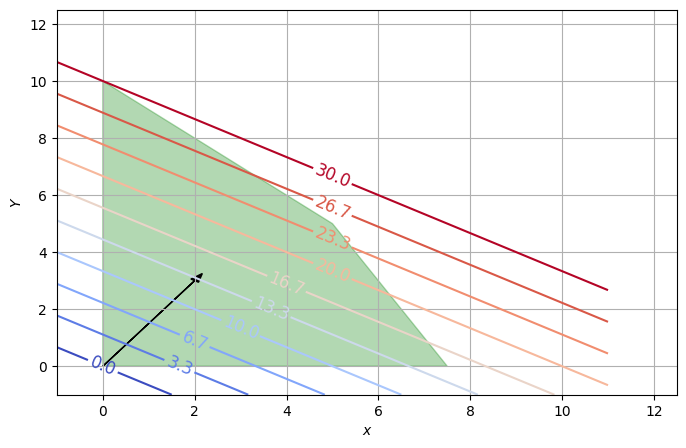

In [3]:
ecken = np.array([[0,0],
               [7.5,0],
               [5,5],
               [0,10]])
delta = 1
x = np.arange(-1, 12, delta)
y = np.arange(-1, 12, delta)
X, Y = np.meshgrid(x, y)

p = np.array([2, 3])
Z = p[0]*X + p[1]*Y

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111)
ax.add_patch(plt.Polygon(ecken, closed=True, color='green', alpha=0.3))
plt.arrow(0, 0, p[0], p[1], head_width=0.2, fc='k')
CS = plt.contour(X, Y, Z, levels= np.linspace(0, 30, 10), cmap= 'coolwarm')
plt.clabel(CS, inline=1, fontsize=12, fmt='%1.1f')
plt.xlim(-1,12.5)
plt.ylim(-1,12.5)
plt.xlabel('$x$')
plt.ylabel('$Y$')
plt.grid(True)

### Aufgabe 2

Lösen Sie das Problem aus der Aufgabe 1 mit linprog

Kostenvektor als Liste erstellen:

In [4]:
c = [-2,-3]

Koeffizientenmatrix der Nebenbedingungen definieren:

In [5]:
A_ub = [[1,1],
        [2,1]]

Grenzwerte der Optimierung in Listenform definieren:

In [6]:
b_ub =[10,15]

Grenzwerte der Optimierungsvariablen in Tuples notieren:

In [7]:
x1_bounds = (0,None)
x2_bounds = (0,None)

Problem mit SciPy.optimize.linprog modellieren und lösen:

In [8]:
from scipy.optimize import linprog
model_linear = linprog(c=c,
                      A_ub=A_ub,
                      b_ub = b_ub,
                      bounds = [x1_bounds,x2_bounds])

Resultat ausgeben

In [9]:
print(str(model_linear))

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -30.0
              x: [ 0.000e+00  1.000e+01]
            nit: 2
          lower:  residual: [ 0.000e+00  1.000e+01]
                 marginals: [ 1.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  5.000e+00]
                 marginals: [-3.000e+00 -0.000e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0


### Aufgabe 3
Plotten Sie die Funktionen

a) $f(x) = \sin(x)^2\log(x)$

In [10]:
from sympy import *
x = symbols('x', real=True)
f = sin(x)**2*log(x)
plot(f,xlim=(0,3), ylim=(-1,2))

ModuleNotFoundError: No module named 'sympy'

b) $f(x_1,x_2) =x_1^2+x_2^2$

In [ ]:
from sympy.plotting import plot3d
x1 = symbols('x1', real=True)
x2 = symbols('x2', real=True)
plot3d(x1**2+x2**2, (x1,1,2), (x2,1,2), xlim = (0.5,2.5), ylim = (0.5,2.5))

### Aufgabe 4

Finden Sie die Quadratwurzel von 2 mit dem Bisektionsverfahren.

In [ ]:
def f(x, rhs): 
    return x**2 - rhs 

def solve(rhs, a = 0, b = 10, tol = 1e-5):
    while True:
        c  = (a + b) / 2.0
        if(f(a, rhs) * f(c, rhs) > 0):
            a = c
        else:
            b = c
        if(abs(f(c, rhs)) < tol):
            break
    return c
y = solve(2.0)
print(solve(2.0))
print(y**2)

### Aufgabe 5

Finden Sie numerisch die Bewegung des harmonischen Oszillators: $y'' + 2\delta y' + \omega^2 y = 0$ mit den Anfangsbedingungen $y(0)=10, \, y'(0)= 0$ und den Parametern $\delta = 0.25,\, \omega = 1$

In [ ]:
delta= 0.25
omega = 1
def rhs(x,t):
    x1_dot=x[1]
    x2_dot=-(2*delta*x[1]+omega**2*x[0])
    return [x1_dot, x2_dot]

Unabhängige Variable (Zeit)

In [ ]:
t=np.arange(0,100,.01) 

Anfangszustand für $x$ und $\dot{x}$

In [ ]:
x0=[10,0]

Aufruf des Integrators

In [ ]:
from scipy.integrate import odeint
x=odeint(rhs, x0, t)

Veranschaulichung der Bewegung

In [ ]:
import matplotlib.pyplot as plt
plt.plot(t, x[:,0], color="green", linewidth=1.0, linestyle="-")